# XGBoost

In this notebook we present the training and evaluation of a XGBoost model on the preprocessed dataset of tennis matches, described previously in `src/notebooks/preprocessing.ipynb`. 

The document is structured as follows:
- **Setup & Imports**: we import the necessary libraries and modules, and build the preprocessing pipeline.
- **Training & Fine-tuning**: we train the model and perform hyperparameter tuning
- **Evaluation**: we evaluate the model on the test set and analyze the results.

# Setup & Imports

In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent 
sys.path.append(str(PROJECT_ROOT))

from typing import cast

from src.data.loader import load_data, train_test_split
from src.data.preprocess import preprocessing_pipeline, create_labels
from src.data.transformers import DropFeatureSelector
from src.features.features import feature_engineering_pipeline
from src.training.training import training_pipeline, fine_tune, feature_selection_pipeline
from src.evaluation.metrics import feature_importance, cross_validation, evaluation_metrics, print_metrics
from src.evaluation.plots import plot_feature_importance, plot_roc_curve, plot_confusion_matrix
from src.utils.utils import get_best_estimator, TSCV

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

import xgboost as xgb

In [3]:
df = load_data()
create_labels(df)
X_train, X_test, y_train, y_test = train_test_split(df)
prep_pipeline : Pipeline = preprocessing_pipeline(X_train, y_train)
feat_pipeline : Pipeline = feature_engineering_pipeline()

preprocessor = Pipeline(
    steps=[
        ("preprocessing", prep_pipeline),
        ("feature_engineering", feat_pipeline),
    ]
)

# Training & Fine Tuning

Firstly, we add the XGBoost Classifier as a step for the pipeline, then the we perform the fine tuning of the hyperparameters using a `RandomizedSearchCV` with 5-fold cross validation.  

In [4]:
xgb_train_pipeline = training_pipeline(model=xgb.XGBClassifier(random_state=42))

pipeline = Pipeline(
        steps = preprocessor.steps + xgb_train_pipeline.steps
    )

hyperparams = {
        'training__n_estimators': [100, 300, 500],
        'training__max_depth': [3, 6, 10],
        'training__learning_rate': [0.01, 0.05, 0.1],
        'training__subsample': [0.6, 0.8, 1.0],
        'training__colsample_bytree': [0.6, 0.8, 1.0],
        'training__min_child_weight': [1, 3, 5],
        'training__gamma': [0, 0.1, 0.3],
        'training__reg_lambda': [1, 5, 10]
    }

search_xgb = fine_tune(
    pipeline=pipeline,
    tuning_methods=RandomizedSearchCV,
    tscv=TSCV,
    hyperparams=hyperparams,
    scoring="accuracy",
    verbose=0,
    random_state=42
)

search_xgb.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'training__colsample_bytree': [0.6, 0.8, ...], 'training__gamma': [0, 0.1, ...], 'training__learning_rate': [0.01, 0.05, ...], 'training__max_depth': [3, 6, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits usin

We derive the best estimator from the search, and we validate the model using cross-validation on the training set.

In [5]:
best_estimator = get_best_estimator(search_xgb)

cross_val_scores = cross_validation(
        pipeline=best_estimator,
        X=X_train,
        y=y_train,
        tscv=TSCV,
        verbose=0,
        scoring="accuracy"
    )

print(pd.Series(cross_val_scores).describe())

count    5.000000
mean     0.676777
std      0.009281
min      0.664184
25%      0.670955
50%      0.679418
75%      0.681449
max      0.687881
dtype: float64


The classifier demonstrated moderate classification performance, achieving an average accuracy of roughly 68% across five cross-validation folds. 
Its low standard deviation suggests that the model's performance is stable and relatively insensitive to the particular dataset on which it was trained.

## Feature Selection

The feature set generated after preprocessing contains many variables, some of which are redundant or weakly related to the target outcome. We perform feature selection before the final XGBoost training, to reduce the noise and model complexity, improving generalization on unseen matches.
Moreover, this method helps identify which tennis statistics are most informative for predicting the winner.

Initially, we extract the feature importance scores from the tuned XGBoost model. 

In [6]:
importances = feature_importance(
    pipeline=best_estimator,
    X=X_train
)

importances

,importance
avg_bet_diff,0.263895
max_bet_diff,0.214163
Tournament_Suisse Open Gstaad,0.011455
Tournament_Sofia Open,0.010267
Tournament_BNP Paribas Open,0.009986
...,...
Tournament_Sydney Tennis Classic,0.000000
Tournament_Mifel Open,0.000000
Tournament_Tel Aviv Open,0.000000
Tournament_U.S. Men's Clay Court Championships,0.000000


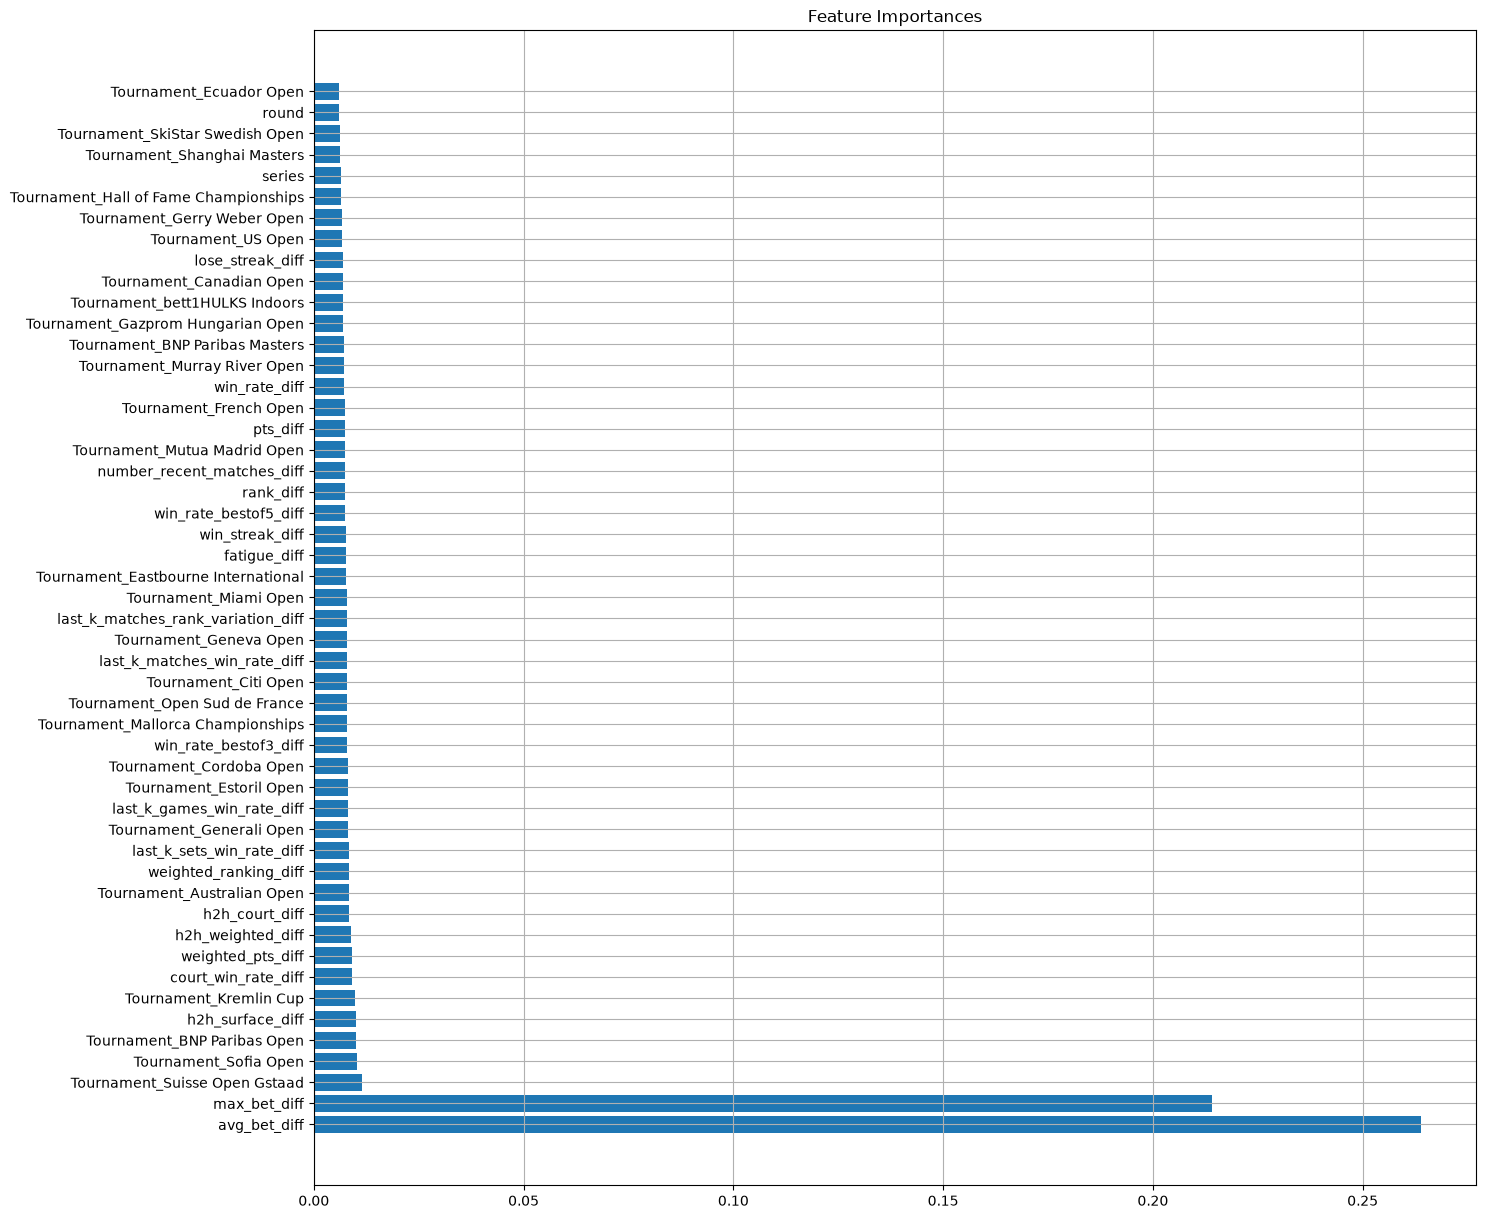

In [7]:
plot_feature_importance(
    feature_names=importances.index.tolist(),
    feature_importances=importances["importance"],
    top_n=50
)

There are clearly two main features that are highly informative for predicting the match outcome
`max_bet_diff` and `avg_bet_diff`.

For the other features, the importance scores are relatively low and similar to each other, indicating that they contribute less to the model's predictive power.

We can try to reduce the number of features by using `RFECV` to find the best subset of features for describing the target variable.

In [8]:
rcevf_pipeline = feature_selection_pipeline(
    model=xgb.XGBClassifier(random_state=42),
    tscv=TSCV,
    min_features_to_select=10,
)

pipeline = Pipeline(
    steps= preprocessor.steps + [
                ("fs", rcevf_pipeline),
            ] + xgb_train_pipeline.steps
    )

search_rf = fine_tune(
    pipeline=pipeline,
    tuning_methods=RandomizedSearchCV,
    tscv=TSCV,
    hyperparams=hyperparams,
    scoring="accuracy",
    verbose=0,
    random_state=42
)

search_rf.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'training__colsample_bytree': [0.6, 0.8, ...], 'training__gamma': [0, 0.1, ...], 'training__learning_rate': [0.01, 0.05, ...], 'training__max_depth': [3, 6, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits usin

In [9]:
best_estimator = get_best_estimator(search_rf)

cross_val_scores = cross_validation(
        pipeline=best_estimator,
        X=X_train,
        y=y_train,
        tscv=TSCV,
        verbose=0,
        scoring="accuracy"
    )

print(pd.Series(cross_val_scores).describe())

count    5.000000
mean     0.677183
std      0.007103
min      0.668246
25%      0.671970
50%      0.678402
75%      0.681449
max      0.685850
dtype: float64


The pipeline reduced the number of features to 66, and the best estimator of the search results still in a stable model, with similar accuracy, however the model is less complex.
Therefore we can define the full pipeline as the best estimator obtained from the search, and the `RFECV` step for feature selection.

In [10]:
full_pipeline_xgb = best_estimator

# Evaluation

We evaluate the full pipeline on the test set.

In [11]:
y_pred = full_pipeline_xgb.predict(X_test)

In [12]:
metrics : dict = evaluation_metrics(
    model=full_pipeline_xgb,
    X_test=X_test,
    y_test=y_test,
    y_pred=y_pred
)

print_metrics(metrics)


Accuracy:
0.6774

Roc Auc:
0.7443

F1:
0.6639

Recall:
0.6547

Confusion Matrix:
      0     1
0  1602   690
1   750  1422


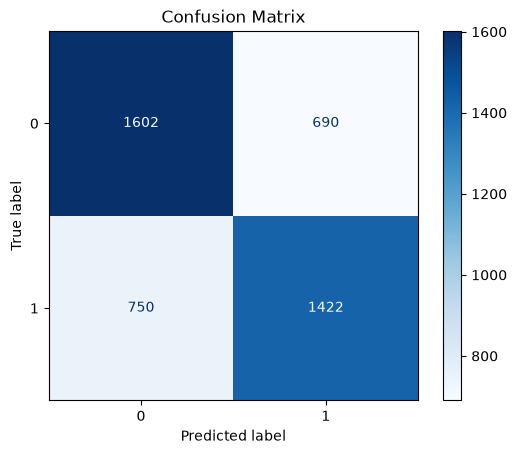

In [13]:
plot_confusion_matrix(cm=metrics["confusion_matrix"])

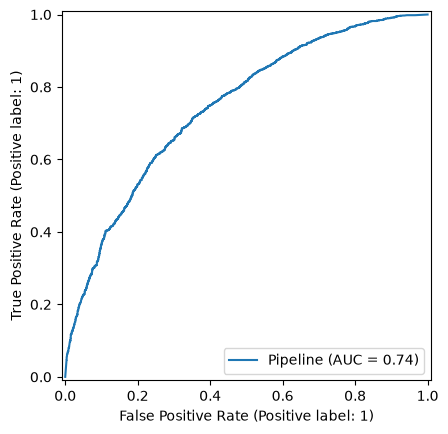

In [14]:
plot_roc_curve(
    model=full_pipeline_xgb,
    X_test=X_test,
    y_test=y_test
)

Recall that the task is a binary classification problem with two players, thus, the goal of the model should be to predict correctly the most amount of matches outcome.
Therefore the main metrics to evaluate the generalization of the model are accuracy and roc-auc:
- The accuracy of the model on unseen matches is nearly 0.68, which is similar to the accuracy obtained during validation.
- The roc-auc score obtained reached 0.74.
- The confusion matrix shows that the model does not favor any player, since the difference between the number of false positives and false negatives is not significant.